In [ ]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.linalg import expm
from quantumScarFunctions import *
from quantumScarsPlotting import *

tau_r = 9.9083


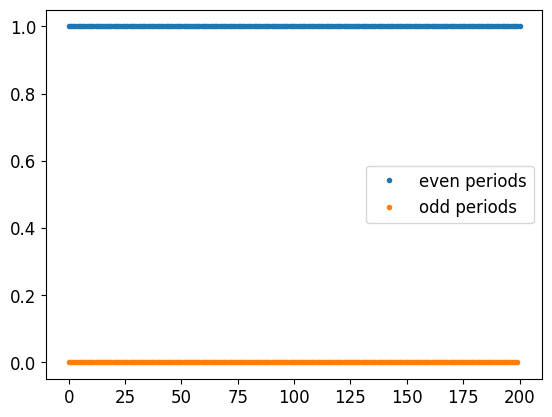

In [55]:
def kicked_scar(N, theta, tau, n_periods, ohms=1.0):
    H0, _, _, psi0, basisList = get_scar_ham(N, ohms=ohms, diagonalize=False)
    H1, _ = get_scar_H1_no_z2(N, basisList)          # sum_i sigma^z_i
    I_diag = get_scar_H1(N, basisList)[0].diag() / N  # imbalance operator

    kick = np.exp(-1j * (theta / 2) * H1.diag())      # theta/2 because H1 = 2*Nop - N
    U_tau = expm(-1j * tau * H0.full())

    z2 = psi0.full().ravel().astype(complex)
    psi = z2.copy()
    fid = np.empty(n_periods + 1)
    imb = np.empty(n_periods + 1)
    fid[0], imb[0] = 1.0, np.real(np.vdot(psi, I_diag * psi))

    for n in range(1, n_periods + 1):
        psi = kick * (U_tau @ psi)                    # evolve first, then kick
        fid[n] = abs(np.vdot(z2, psi)) ** 2
        imb[n] = np.real(np.vdot(psi, I_diag * psi))

    return fid, imb

N = 12
H0, w, v, psi0, _ = get_scar_ham(N)
amp = np.array([s.overlap(psi0) for s in v])
ts = np.linspace(2, 15, 20000)
f = np.abs((np.abs(amp)**2) @ np.exp(-1j * np.outer(w, ts)))**2
tau_r = ts[np.argmax(f)]
print(f"tau_r = {tau_r:.4f}")

fid, imb = kicked_scar(N=N, theta=np.pi, tau=0.993*tau_r/2, n_periods=400)

plt.plot(fid[0::2], '.', label='even periods')
plt.plot(fid[1::2], '.', label='odd periods')
plt.legend()
plt.show()